<a href="https://colab.research.google.com/github/suyz1213/cs666student/blob/main/CS666_Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

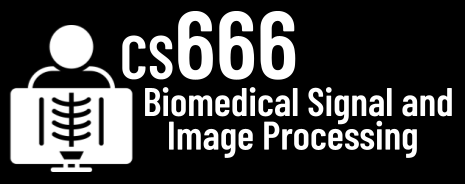
#Assignment 4

In [ ]:
# NAME: Yaozong Su

In [ ]:
# In this assignment, we will create a Random Forest classifier to detect pneumonia and covid in xrays!

In [ ]:
# load numpy and matplotlib
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [ ]:
# we are using mahotas again, so lets install it!
!pip install mahotas

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
# our imports include sklearn this time
import mahotas as mh
import os
from sklearn.ensemble import RandomForestClassifier

**Task 1:** Download, extract, and load the data! [15 Points]

In [ ]:
# Please download this file: https://cs666.org/data/xray/ with the wget command!
# Note: Please use the forwarded dropbox link and change dl=0 to dl=1!
# This is a subset of the Kaggle Pneumonia + Covid Datasets!

In [ ]:
!wget "https://www.dropbox.com/scl/fi/sso8jwvfhoxqarp4zd3fb/xray.zip?rlkey=rvjqu3yj6gmw3r7gmst4ke9fl&e=1&dl=1" -O xray.zip

--2026-04-19 10:47:24--  https://www.dropbox.com/scl/fi/sso8jwvfhoxqarp4zd3fb/xray.zip?rlkey=rvjqu3yj6gmw3r7gmst4ke9fl&e=1&dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.4.18, 2620:100:601c:18::a27d:612
Connecting to www.dropbox.com (www.dropbox.com)|162.125.4.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc6aabaad67cb5dcf25954dbe22a.dl.dropboxusercontent.com/cd/0/inline/C-4ojWgb6DGquurkFMK3206PhdTRGqV7ztbLewaF6PeAgV-tK1oMwpLYgJPco8AyIN0_vFTEh2r0uW96UpSZRRrQ0mkHqfIcegoe57WSa0PjNsvsoFI4U7DG26xIBljDHUE/file?dl=1# [following]
--2026-04-19 10:47:25--  https://uc6aabaad67cb5dcf25954dbe22a.dl.dropboxusercontent.com/cd/0/inline/C-4ojWgb6DGquurkFMK3206PhdTRGqV7ztbLewaF6PeAgV-tK1oMwpLYgJPco8AyIN0_vFTEh2r0uW96UpSZRRrQ0mkHqfIcegoe57WSa0PjNsvsoFI4U7DG26xIBljDHUE/file?dl=1
Resolving uc6aabaad67cb5dcf25954dbe22a.dl.dropboxusercontent.com (uc6aabaad67cb5dcf25954dbe22a.dl.dropboxusercontent.com)... 162.125.4.15, 2620:100:601c:15::a27d:60f
Connec

In [ ]:
# Run this code to extract the zip file and to create
# the folder structure of normal/, pneumonia/, and covid/ images.
# Each folder contains the first images of the Kaggle datasets.
import zipfile
with zipfile.ZipFile('xray.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

NORMAL_DIR = 'normal/'
PNEUMONIA_DIR = 'pneumonia/'
COVID_DIR = 'covid/'

In [ ]:
# Here we load the first image from the normal dataset.
img = mh.imread(NORMAL_DIR + 'IM-0115-0001.jpeg')

In [ ]:
# TODO: Please display this image and print the dimensions!

In [ ]:
# TODO: YOUR CODE

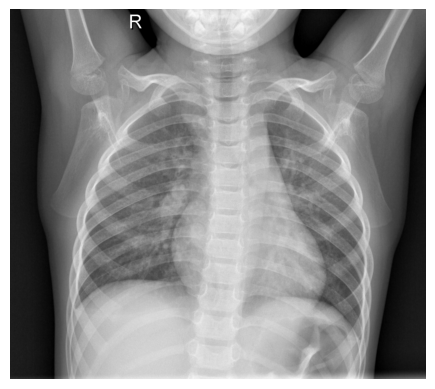

(1858, 2090)


In [ ]:
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

print(img.shape)

**Task 2:** Let's do some data wrangling and more visualization! [30 Points]

In [ ]:
folders = [NORMAL_DIR, PNEUMONIA_DIR, COVID_DIR]
data = [[],[],[]]

for f_index,f in enumerate( folders ):
  all_files = os.listdir( f )

  data[f_index] = np.zeros( (len(all_files), 300, 300), dtype=np.float32)

  for i in range(len(all_files)):
    loaded_image = mh.imread( f + '/' + all_files[i] )
    if loaded_image.ndim > 2:
      loaded_image = mh.colors.rgb2gray(loaded_image[:,:,:3])

    loaded_image = mh.imresize( loaded_image, (300, 300) )
    img_shape = loaded_image.shape

    data[f_index][ i, 0:img_shape[0], 0:img_shape[1] ] = loaded_image

In [ ]:
# The two code blocks above perform 3 data wrangling operations.
# Which ones?
# Hint: The first two might be more obvious but the third one happens in the
# last line.
# TODO: Operation 1) Convert RGB images to grayscale;
# TODO: Operation 2) Resize images to a fixed shape (300 × 300);
# TODO: Operation 3) Pack images into a structured tensor

In [ ]:
# Now, let's look at the first 5 normal_images and the first 5 pneumonia_images.
# TODO: Please visualize multiple images at once.
# Hint: You can use one of the following answers from StackOverflow for this:
# https://stackoverflow.com/questions/41210823/using-plt-imshow-to-display-multiple-images

In [ ]:
# TODO: YOUR CODE

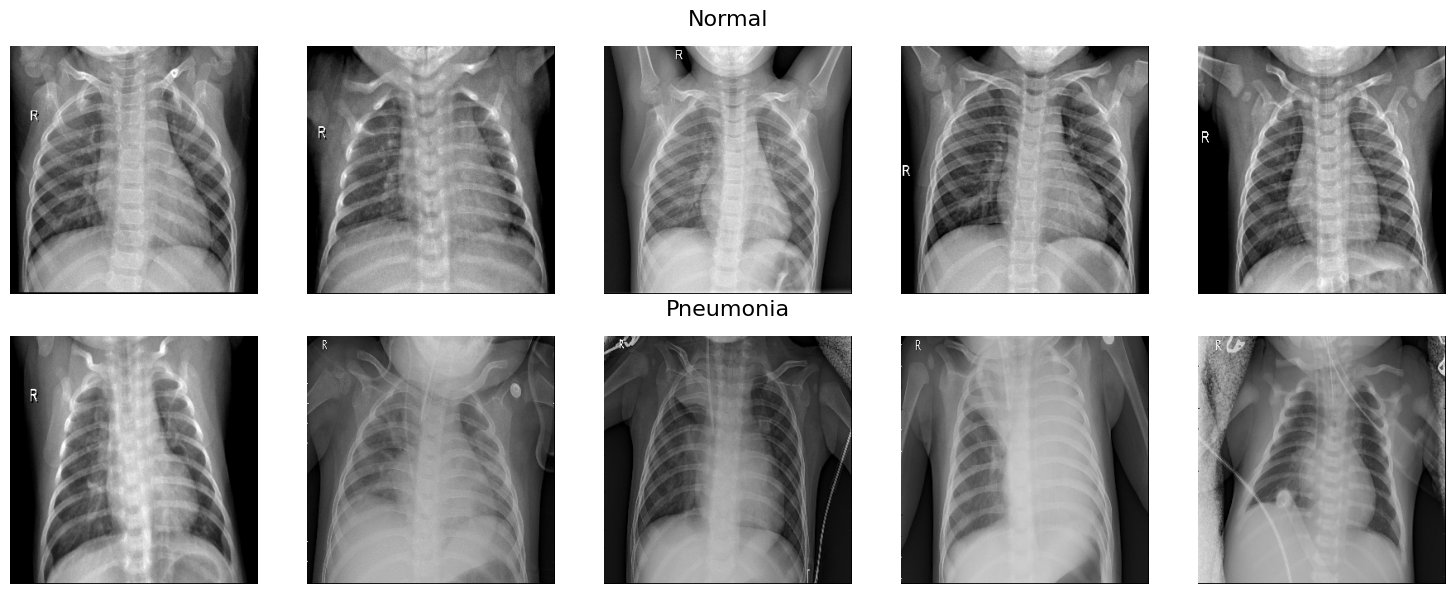

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# first 5 in normal
for i in range(5):
    axes[0, i].imshow(data[0][i], cmap='gray')
    axes[0, i].axis('off')

# first 5 in pneumonia
for i in range(5):
    axes[1, i].imshow(data[1][i], cmap='gray')
    axes[1, i].axis('off')

axes[0, 2].set_title("Normal", fontsize=16, pad=15)
axes[1, 2].set_title("Pneumonia", fontsize=16, pad=15)

plt.tight_layout()
plt.show()

**Task 3:** Setup training and testing data. [15 Points]

In [ ]:
# Any supervised machine learning algorithm requires disjunct sets of
# training and testing data.
#
# For each, we will create a balanced dataset that includes an equal number
# of normal xrays, pneumonia xrays, and covid xrays.
#
# The training data X_train will include 180 images (60 normal, 60 pneumonia, 60 covid).
# The testing data X_test will include the remaining 120 images (40 normal, 40 pneumonia, 40 covid).
#
# Supervised learning means that we tell the algorithm which image is normal
# and which image is pneumonia. For this, we need the y_train vector.
# The vector shall be 0 for a normal image, and 1 for a pneumonia, and 2 for a covid scan.

In [ ]:
TRAINING_COUNT = 60

X_train = np.zeros( (TRAINING_COUNT * 3, 300*300 ), dtype=np.float32)
t_pos = 0

for d in data:
  for image in d[0:TRAINING_COUNT]:
    image = image.ravel() # flatten the image
    image /= image.max() # normalize the image
    X_train[t_pos] = image
    t_pos += 1

In [ ]:
# TODO: Please create the y_train vector with 0 for a normal image,
# 1 for a pneumonia, and 2 for covid. This needs to a numpy array.
y_train = np.array([0]*60 + [1]*60 + [2]*60, dtype=np.int64)
y_train

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2])

In [ ]:
TESTING_COUNT = 40

X_test = np.zeros( (TESTING_COUNT * 3, 300*300 ), dtype=np.float32)
t_pos = 0

for d in data:
  for image in d[TRAINING_COUNT:TRAINING_COUNT+TESTING_COUNT]:
    image = image.ravel() # flatten the image
    image /= image.max() # normalize the image
    X_test[t_pos] = image
    t_pos += 1

In [ ]:
# TODO: Please create the y_test vector with 0 for a normal image,
# 1 for a pneumonia, and 2 for covid. This needs to a numpy array.
y_test = np.array([0]*40 + [1]*40 + [2]*40, dtype=np.int64)
y_test

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

**Task 4:** Let's train and evaluate the Random Forest! [30 Points]

In [ ]:
# Let's shuffle our training data.
p = np.random.permutation(len(X_train))
X_train = X_train[p]
y_train = y_train[p]

In [ ]:
# With scikit-learn, we can easily set up a default Random Forest classifier.
clf = RandomForestClassifier()

In [ ]:
# Now, we train the classifier with the training data and the training targets.
# We essentially show the classifier an image and tell whether the image is
# normal or pneumonia or covid.
fitted = clf.fit( X_train, y_train )

In [ ]:
# TODO: In just a few sentences, please explain how the Random Forest works.

In [ ]:
# TODO: Random forrest classifier is an emsemble classification method.
# It performs classficication by training multiple decision trees to cast votes;
# Each tree is trained using randomly sampled data and random features to enhance model diversity;
# The final result is determined by a majority vote among all the trees.

In [ ]:
# After training, we can see how well the classifier predicts our testing data.
# The following command will return the classification accuracy.
clf.score( X_test, y_test )

0.8916666666666667

In [ ]:
# TODO: Is the classification accuracy good? And, are you surprised?

In [ ]:
# TODO: I think this accuracy is pretty good and I'm not surprised.
# Because I have seen some papers reporting high accuracy on similar tasks;
# In addition, this dataset is relatively simple and we actually don't need to do a lot of data pre-processing.

**Task 5:** Now, let's decrease the number of trees! [10 Points]

In [ ]:
# How many trees are used in Task 4?

In [ ]:
print(clf.n_estimators)

100


In [ ]:
# Now, please use a single tree and observe the testing performance.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()
fitted = dtc.fit(X_train, y_train)

In [ ]:
dtc.score( X_test, y_test )

0.75

In [ ]:
# Are you surprised?

In [ ]:
# TODO: No. It should be lower.
# Because a single tree is more prone to overfitting.

**Bonus:** Let's take a closer look! [33 Points]

In [ ]:
# Let's run the fitted classifier on the remaining covid images.
# You might have noticed that there are 199 covid images but we only used 100 so far.
# Please evaluate the classifier on the remaining (previously unseen) 99 covid images
# and check the performance.

In [ ]:
data[2].shape

(199, 300, 300)

In [ ]:
covid_remain = data[2][100:]
covid_remain.shape

(99, 300, 300)

In [ ]:
X_covid_remain = np.zeros((len(covid_remain), 300*300), dtype=np.float32)

for i, image in enumerate(covid_remain):
    image = image.ravel()
    image /= image.max()
    X_covid_remain[i] = image

In [ ]:
y_pred = clf.predict(X_covid_remain)

In [ ]:
y_true = np.full(len(X_covid_remain), 2)

accuracy = (y_pred == y_true).mean()
print(accuracy)

0.9393939393939394


In [ ]:
# Can you figure out which images were misclassified?
# Hint: You can use predictions = clf.predict(X_test_covid_only) for this.
# Can you display them?
# Do you have an idea why these images were problematic?

In [ ]:
pred_wrong_idx = np.where(y_pred != 2)[0]
pred_wrong_idx

array([14, 32, 34, 63, 73, 91])

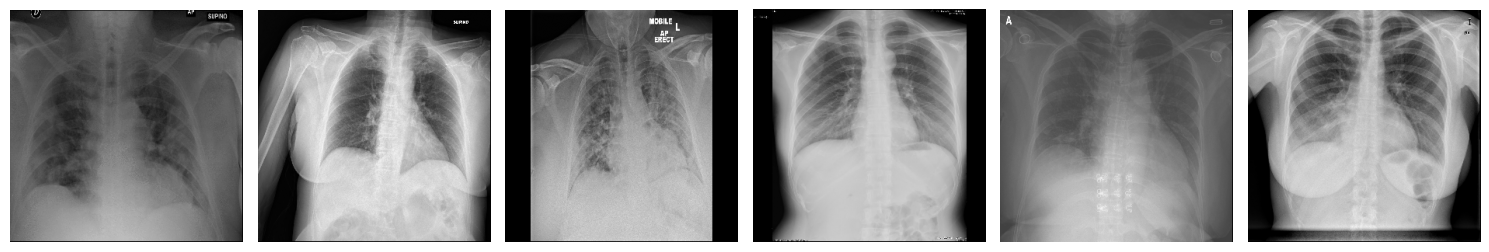

In [ ]:
fig, axes = plt.subplots(1, 6, figsize=(15, 6))

for i in range(len(pred_wrong_idx)):
    img = X_covid_remain[pred_wrong_idx[i]].reshape(300, 300)
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# TODO: The intensity of the white opacities in these few COVID images is not as high as in the others.

In [ ]:
# Great job!!!
#           ___
#       _.-'   \
#      /        \
#     /          \
#    /            `.___
#   ( .--.)\/(,.--.    `-.
#   ,',-. \   / ,-.`.     )
#  ( /   \     /   \ )   / \
#   || .-|     |-. ||---'|  \
#  _|| | |     | | ||_   |   \
# /. \ |_|.---.|_| / ,\  | .^.\
# `.\ `--"     "--' /,'  |/
#   `>  _________ <'
# ,-' ,---.---.---. `-.
# `--'\    \j/    /`--'
#    `.\         /,'
#      \\_______//
#       `-------'       hjw